In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
import pandas as pd

# Define the data directory
DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data2.0/"
# define the Plot directory
PLOT_DIRECTORY = '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Plots2.0/'

# Define the cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
h = 0.7

redshifts = np.array([4, 5, 6, 7, 8, 9, 10])
red_com = cosmo.comoving_distance(redshifts).value * h #h^-1 Mpc

z_min = 4
z_max = 10

# Calculate the comoving distances
com_dist_min = cosmo.comoving_distance(z_min).value * h
com_dist_max = cosmo.comoving_distance(z_max).value * h

# Define the pixel size in z
pixel_size_z = 2.0

new_z_axis = np.arange(com_dist_min, com_dist_max, pixel_size_z)

# Define the gaussian function
def gaussian(x, mu, sig, gaus_peak):
    return 1 - gaus_peak * np.exp(-np.power(x - mu, 2.) / (2 * np.power(sig, 2.)))

# Define the  gaussian function
def gaussian2(x, mu1, sig1, gaus_peak1, mu2, sig2, gaus_peak2):
    return 1 - gaus_peak1 * np.exp(-np.power(x - mu1, 2.) / (2 * np.power(sig1, 2.))) - gaus_peak2 * np.exp(-np.power(x - mu2, 2.) / (2 * np.power(sig2, 2.)))

# Define the plot style
plt.style.use('MNRAS_Style.mplstyle')

In [2]:
red_com[0]+50

5069.256490124303

In [3]:
red_com[1]

5442.7593468240075

In [4]:
red_com[2]

5772.844019771492

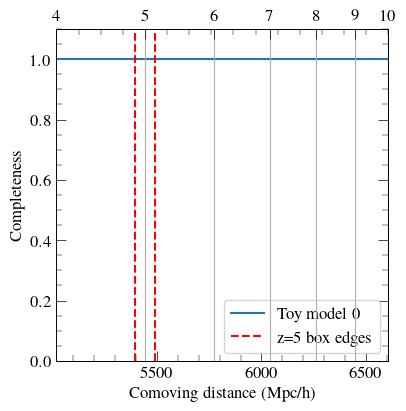

In [2]:
# Toy0 model
# Plot the selection function
fig, ax = plt.subplots()
ax.plot(new_z_axis, np.ones_like(new_z_axis), label='Toy model 0')
ax.axvline(5392.76, color='r', linestyle='--', label='z=5 box edges')
ax.axvline(5492.76, color='r', linestyle='--')

ax.set_xlabel('Comoving distance (Mpc/h)')
ax.set_ylabel('Completeness')
ax.legend()
ax.grid(visible=False)
ax.set_box_aspect(1)
ax.set_ylim(0, 1.1)

# Add another twin axis for redshift
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(red_com)
ax2.set_xticklabels(redshifts)
ax2.set_box_aspect(1)

# save the plot as a pdf
plt.savefig(PLOT_DIRECTORY + 'Toy0_SelectionFunction.pdf', bbox_inches='tight')
plt.show()

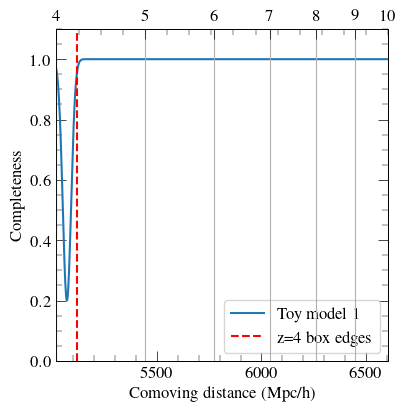

Average probability of detection:  1.0


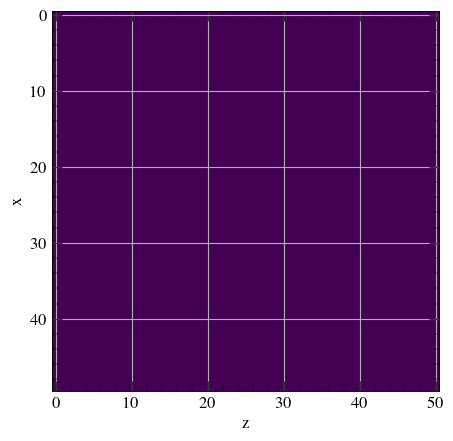

In [2]:
# toy1 model

func = gaussian(new_z_axis, red_com[0]+50, 20, 0.8)

# save new_z_axis and func as a dictionary into a csv file
selection_function_data = {'z_axis': new_z_axis, 'func': func}
selection_function_df = pd.DataFrame(selection_function_data)

# Save the data as a CSV file
csv_file_path = DATA_DIRECTORY + "toy1_SelectionFunction.csv"
selection_function_df.to_csv(csv_file_path, index=False)

fig, ax = plt.subplots()
ax.plot(new_z_axis, func, label='Toy model 1')
ax.axvline(red_com[0], color='r', linestyle='--', label='z=4 box edges')
ax.axvline(red_com[0]+100, color='r', linestyle='--')

ax.set_xlabel('Comoving distance (Mpc/h)')
ax.set_ylabel('Completeness')
ax.legend()
ax.grid(visible=False)
ax.set_box_aspect(1)
ax.set_ylim(0, 1.1)

# Add another twin axis for redshift
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(red_com)
ax2.set_xticklabels(redshifts)
ax2.set_box_aspect(1)

# save the plot as a pdf
plt.savefig(PLOT_DIRECTORY + 'Toy1_SelectionFunction.pdf', bbox_inches='tight')
plt.show()
# Let me first define the box around z=5. So we know the 100 cMpc/h box around z=5. It is given by red_com[1]-50 to red_com[1]+50.
# Now new_z_axis gives the comoving distance of the pixel centers. Left edge of the pixel is given by new_z_axis - pixel_size_z/2 and 
# right edge of the pixel is given by new_z_axis + pixel_size_z/2.
index = np.where(((new_z_axis+pixel_size_z/2) >= red_com[1]-50) & ((new_z_axis-pixel_size_z/2) <= red_com[1]+50))

# Defining the incomplete function.
incomp_func = np.ones((50, 50, 795)) * func

# now I want to visualize the incomp_func with these indices
incomp_func2d = np.average(incomp_func[:, :, index[0]], axis=0)
plt.figure(figsize=(5, 5))
plt.imshow(incomp_func2d)
plt.xlabel('z')
plt.ylabel('x')

# Find the fraction of quasar we will detect if the number of quasars is n->infinity.
print("Average probability of detection: ", np.average(incomp_func[:, :, index]))

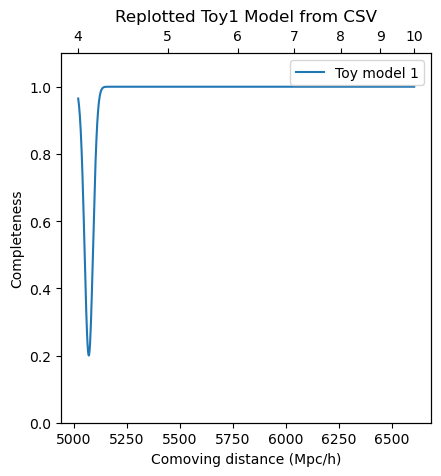

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from astropy.cosmology import FlatLambdaCDM

# Define the data directory
DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data2.0/"

# Define the cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
h = 0.7

redshifts = np.array([4, 5, 6, 7, 8, 9, 10])
red_com = cosmo.comoving_distance(redshifts).value * h #h^-1 Mpc

# Load the selection function data from the CSV file
csv_file_path =  DATA_DIRECTORY + "Toy1_SelectionFunction.csv"
selection_function_df = pd.read_csv(csv_file_path)

# Extract new_z_axis and func from the loaded data
new_z_axis = selection_function_df['z_axis']
func = selection_function_df['func']

# Replot the Toy1 model
fig, ax = plt.subplots()
ax.plot(new_z_axis, func, label='Toy 1 model')
# ax.axvline(500, color='r', linestyle='--', label='z=5 box edges')  # Replace 500 with red_com[0] if available
# ax.axvline(600, color='r', linestyle='--')  # Replace 600 with red_com[0]+100 if available

ax.set_xlabel('Comoving distance (Mpc/h)')
ax.set_ylabel('Completeness')
ax.legend()
ax.grid(visible=False)
ax.set_box_aspect(1)
ax.set_ylim(0, 1.1)

# Add another twin axis for redshift
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(red_com)
ax2.set_xticklabels(redshifts)
ax2.set_box_aspect(1)

plt.title("Replotted Toy1 Model from CSV")
plt.show()


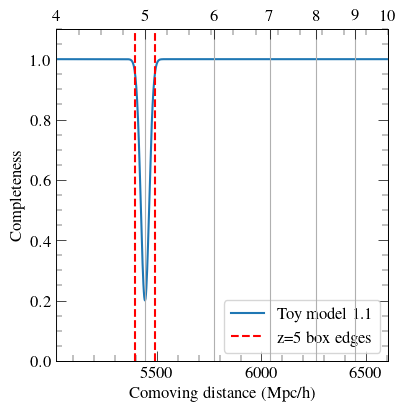

Average probability of detection:  0.6110356998543397


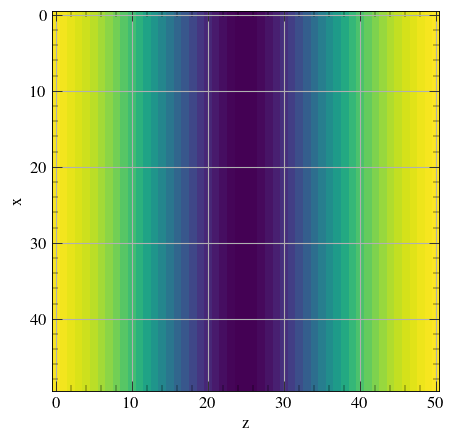

In [8]:
# toy1.1 model

func = gaussian(new_z_axis, red_com[1], 20, 0.8)

# save new_z_axis and func as a dictionary into a csv file
selection_function_data = {'z_axis': new_z_axis, 'func': func}
selection_function_df = pd.DataFrame(selection_function_data)

# Save the data as a CSV file
csv_file_path = DATA_DIRECTORY + "toy1.1_SelectionFunction.csv"
selection_function_df.to_csv(csv_file_path, index=False)

fig, ax = plt.subplots()
ax.plot(new_z_axis, func, label='Toy model 1.1')
ax.axvline(5392.76, color='r', linestyle='--', label='z=5 box edges')
ax.axvline(5492.76, color='r', linestyle='--')

ax.set_xlabel('Comoving distance (Mpc/h)')
ax.set_ylabel('Completeness')
ax.legend()
ax.grid(visible=False)
ax.set_box_aspect(1)
ax.set_ylim(0, 1.1)

# Add another twin axis for redshift
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(red_com)
ax2.set_xticklabels(redshifts)
ax2.set_box_aspect(1)

# save the plot as a pdf
plt.savefig(PLOT_DIRECTORY + 'Toy1.1_SelectionFunction.pdf', bbox_inches='tight')
plt.show()
# Let me first define the box around z=5. So we know the 100 cMpc/h box around z=5. It is given by red_com[1]-50 to red_com[1]+50.
# Now new_z_axis gives the comoving distance of the pixel centers. Left edge of the pixel is given by new_z_axis - pixel_size_z/2 and 
# right edge of the pixel is given by new_z_axis + pixel_size_z/2.
index = np.where(((new_z_axis+pixel_size_z/2) >= red_com[1]-50) & ((new_z_axis-pixel_size_z/2) <= red_com[1]+50))

# Defining the incomplete function.
incomp_func = np.ones((50, 50, 795)) * func

# now I want to visualize the incomp_func with these indices
incomp_func2d = np.average(incomp_func[:, :, index[0]], axis=0)
plt.figure(figsize=(5, 5))
plt.imshow(incomp_func2d)
plt.xlabel('z')
plt.ylabel('x')

# Find the fraction of quasar we will detect if the number of quasars is n->infinity.
print("Average probability of detection: ", np.average(incomp_func[:, :, index]))

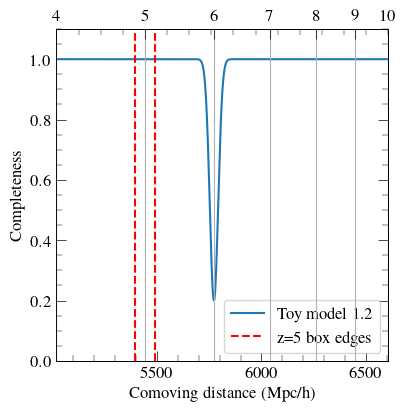

Average probability of detection:  1.0


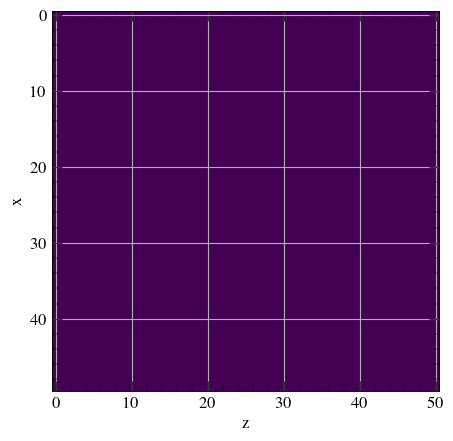

In [12]:
# toy1.2 model

func = gaussian(new_z_axis, red_com[2], 20, 0.8)

# save new_z_axis and func as a dictionary into a csv file
selection_function_data = {'z_axis': new_z_axis, 'func': func}
selection_function_df = pd.DataFrame(selection_function_data)

# Save the data as a CSV file
csv_file_path = DATA_DIRECTORY + "toy1.2_SelectionFunction.csv"
selection_function_df.to_csv(csv_file_path, index=False)

fig, ax = plt.subplots()
ax.plot(new_z_axis, func, label='Toy model 1.2')
ax.axvline(5392.76, color='r', linestyle='--', label='z=5 box edges')
ax.axvline(5492.76, color='r', linestyle='--')

ax.set_xlabel('Comoving distance (Mpc/h)')
ax.set_ylabel('Completeness')
ax.legend()
ax.grid(visible=False)
ax.set_box_aspect(1)
ax.set_ylim(0, 1.1)

# Add another twin axis for redshift
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(red_com)
ax2.set_xticklabels(redshifts)
ax2.set_box_aspect(1)

# save the plot as a pdf
plt.savefig(PLOT_DIRECTORY + 'Toy1.2_SelectionFunction.pdf', bbox_inches='tight')
plt.show()
# Let me first define the box around z=5. So we know the 100 cMpc/h box around z=5. It is given by red_com[1]-50 to red_com[1]+50.
# Now new_z_axis gives the comoving distance of the pixel centers. Left edge of the pixel is given by new_z_axis - pixel_size_z/2 and 
# right edge of the pixel is given by new_z_axis + pixel_size_z/2.
index = np.where(((new_z_axis+pixel_size_z/2) >= red_com[1]-50) & ((new_z_axis-pixel_size_z/2) <= red_com[1]+50))

# Defining the incomplete function.
incomp_func = np.ones((50, 50, 795)) * func

# now I want to visualize the incomp_func with these indices
incomp_func2d = np.average(incomp_func[:, :, index[0]], axis=0)
plt.figure(figsize=(5, 5))
plt.imshow(incomp_func2d)
plt.xlabel('z')
plt.ylabel('x')

# Find the fraction of quasar we will detect if the number of quasars is n->infinity.
print("Average probability of detection: ", np.average(incomp_func[:, :, index]))

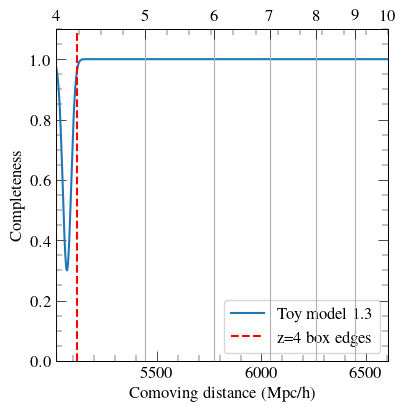

Average probability of detection:  1.0


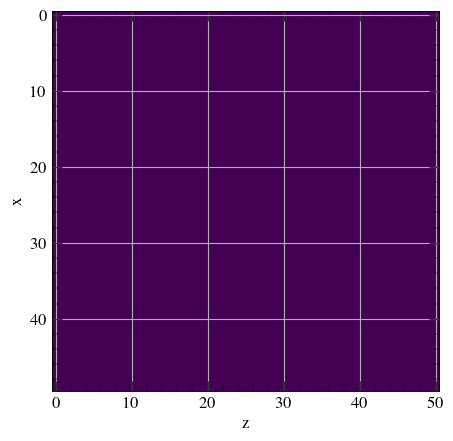

In [13]:
# toy1.3 model

func = gaussian(new_z_axis, red_com[0]+50, 20, 0.7)

# save new_z_axis and func as a dictionary into a csv file
selection_function_data = {'z_axis': new_z_axis, 'func': func}
selection_function_df = pd.DataFrame(selection_function_data)

# Save the data as a CSV file
csv_file_path = DATA_DIRECTORY + "toy1.3_SelectionFunction.csv"
selection_function_df.to_csv(csv_file_path, index=False)

fig, ax = plt.subplots()
ax.plot(new_z_axis, func, label='Toy model 1.3')
ax.axvline(red_com[0], color='r', linestyle='--', label='z=4 box edges')
ax.axvline(red_com[0]+100, color='r', linestyle='--')

ax.set_xlabel('Comoving distance (Mpc/h)')
ax.set_ylabel('Completeness')
ax.legend()
ax.grid(visible=False)
ax.set_box_aspect(1)
ax.set_ylim(0, 1.1)

# Add another twin axis for redshift
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(red_com)
ax2.set_xticklabels(redshifts)
ax2.set_box_aspect(1)

# save the plot as a pdf
plt.savefig(PLOT_DIRECTORY + 'Toy1.3_SelectionFunction.pdf', bbox_inches='tight')
plt.show()
# Let me first define the box around z=5. So we know the 100 cMpc/h box around z=5. It is given by red_com[1]-50 to red_com[1]+50.
# Now new_z_axis gives the comoving distance of the pixel centers. Left edge of the pixel is given by new_z_axis - pixel_size_z/2 and 
# right edge of the pixel is given by new_z_axis + pixel_size_z/2.
index = np.where(((new_z_axis+pixel_size_z/2) >= red_com[1]-50) & ((new_z_axis-pixel_size_z/2) <= red_com[1]+50))

# Defining the incomplete function.
incomp_func = np.ones((50, 50, 795)) * func

# now I want to visualize the incomp_func with these indices
incomp_func2d = np.average(incomp_func[:, :, index[0]], axis=0)
plt.figure(figsize=(5, 5))
plt.imshow(incomp_func2d)
plt.xlabel('z')
plt.ylabel('x')

# Find the fraction of quasar we will detect if the number of quasars is n->infinity.
print("Average probability of detection: ", np.average(incomp_func[:, :, index]))

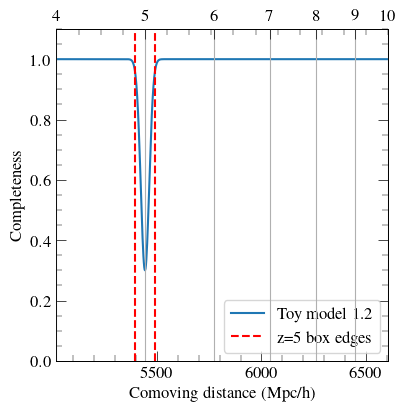

Average probability of detection:  0.6596562373725472


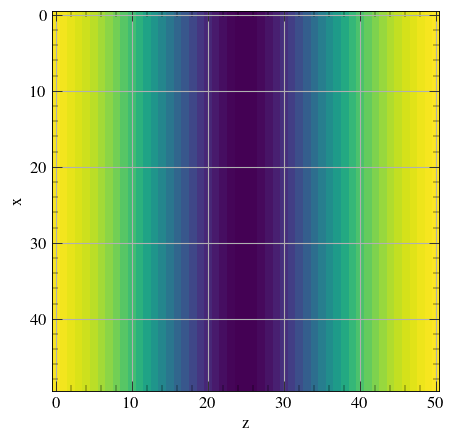

In [7]:
# toy1.4 model

func = gaussian(new_z_axis, red_com[1], 20, 0.7)

fig, ax = plt.subplots()
ax.plot(new_z_axis, func, label='Toy model 1.2')
ax.axvline(5392.76, color='r', linestyle='--', label='z=5 box edges')
ax.axvline(5492.76, color='r', linestyle='--')

ax.set_xlabel('Comoving distance (Mpc/h)')
ax.set_ylabel('Completeness')
ax.legend()
ax.grid(visible=False)
ax.set_box_aspect(1)
ax.set_ylim(0, 1.1)

# Add another twin axis for redshift
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(red_com)
ax2.set_xticklabels(redshifts)
ax2.set_box_aspect(1)

# save the plot as a pdf
plt.savefig(PLOT_DIRECTORY + 'Toy1.1_SelectionFunction.pdf', bbox_inches='tight')
plt.show()
# Let me first define the box around z=5. So we know the 100 cMpc/h box around z=5. It is given by red_com[1]-50 to red_com[1]+50.
# Now new_z_axis gives the comoving distance of the pixel centers. Left edge of the pixel is given by new_z_axis - pixel_size_z/2 and 
# right edge of the pixel is given by new_z_axis + pixel_size_z/2.
index = np.where(((new_z_axis+pixel_size_z/2) >= red_com[1]-50) & ((new_z_axis-pixel_size_z/2) <= red_com[1]+50))

# Defining the incomplete function.
incomp_func = np.ones((50, 50, 795)) * func

# now I want to visualize the incomp_func with these indices
incomp_func2d = np.average(incomp_func[:, :, index[0]], axis=0)
plt.figure(figsize=(5, 5))
plt.imshow(incomp_func2d)
plt.xlabel('z')
plt.ylabel('x')

# Find the fraction of quasar we will detect if the number of quasars is n->infinity.
print("Average probability of detection: ", np.average(incomp_func[:, :, index]))

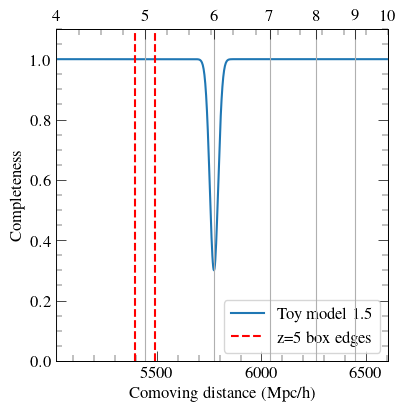

Average probability of detection:  1.0


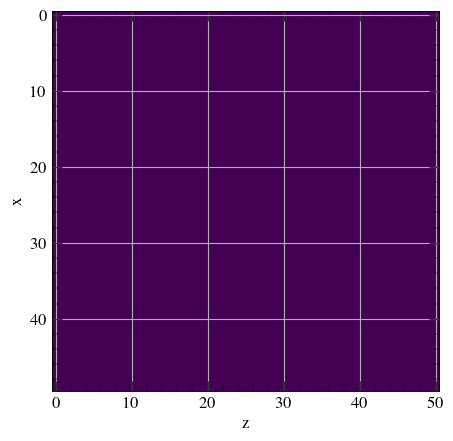

In [8]:
# toy1.5 model

func = gaussian(new_z_axis, red_com[2], 20, 0.7)

fig, ax = plt.subplots()
ax.plot(new_z_axis, func, label='Toy model 1.5')
ax.axvline(5392.76, color='r', linestyle='--', label='z=5 box edges')
ax.axvline(5492.76, color='r', linestyle='--')

ax.set_xlabel('Comoving distance (Mpc/h)')
ax.set_ylabel('Completeness')
ax.legend()
ax.grid(visible=False)
ax.set_box_aspect(1)
ax.set_ylim(0, 1.1)

# Add another twin axis for redshift
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(red_com)
ax2.set_xticklabels(redshifts)
ax2.set_box_aspect(1)

# save the plot as a pdf
plt.savefig(PLOT_DIRECTORY + 'Toy1.5_SelectionFunction.pdf', bbox_inches='tight')
plt.show()
# Let me first define the box around z=5. So we know the 100 cMpc/h box around z=5. It is given by red_com[1]-50 to red_com[1]+50.
# Now new_z_axis gives the comoving distance of the pixel centers. Left edge of the pixel is given by new_z_axis - pixel_size_z/2 and 
# right edge of the pixel is given by new_z_axis + pixel_size_z/2.
index = np.where(((new_z_axis+pixel_size_z/2) >= red_com[1]-50) & ((new_z_axis-pixel_size_z/2) <= red_com[1]+50))

# Defining the incomplete function.
incomp_func = np.ones((50, 50, 795)) * func

# now I want to visualize the incomp_func with these indices
incomp_func2d = np.average(incomp_func[:, :, index[0]], axis=0)
plt.figure(figsize=(5, 5))
plt.imshow(incomp_func2d)
plt.xlabel('z')
plt.ylabel('x')

# Find the fraction of quasar we will detect if the number of quasars is n->infinity.
print("Average probability of detection: ", np.average(incomp_func[:, :, index]))

In [ ]:
# toy1.6 model

func = gaussian(new_z_axis, red_com[0]+50, 20, 0.9)

fig, ax = plt.subplots()
ax.plot(new_z_axis, func, label='Toy model 1.5')
ax.axvline(5392.76, color='r', linestyle='--', label='z=5 box edges')
ax.axvline(5492.76, color='r', linestyle='--')

ax.set_xlabel('Comoving distance (Mpc/h)')
ax.set_ylabel('Completeness')
ax.legend()
ax.grid(visible=False)
ax.set_box_aspect(1)
ax.set_ylim(0, 1.1)

# Add another twin axis for redshift
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(red_com)
ax2.set_xticklabels(redshifts)
ax2.set_box_aspect(1)

# save the plot as a pdf
plt.savefig(PLOT_DIRECTORY + 'Toy1.5_SelectionFunction.pdf', bbox_inches='tight')
plt.show()
# Let me first define the box around z=5. So we know the 100 cMpc/h box around z=5. It is given by red_com[1]-50 to red_com[1]+50.
# Now new_z_axis gives the comoving distance of the pixel centers. Left edge of the pixel is given by new_z_axis - pixel_size_z/2 and 
# right edge of the pixel is given by new_z_axis + pixel_size_z/2.
index = np.where(((new_z_axis+pixel_size_z/2) >= red_com[1]-50) & ((new_z_axis-pixel_size_z/2) <= red_com[1]+50))

# Defining the incomplete function.
incomp_func = np.ones((50, 50, 795)) * func

# now I want to visualize the incomp_func with these indices
incomp_func2d = np.average(incomp_func[:, :, index[0]], axis=0)
plt.figure(figsize=(5, 5))
plt.imshow(incomp_func2d)
plt.xlabel('z')
plt.ylabel('x')

# Find the fraction of quasar we will detect if the number of quasars is n->infinity.
print("Average probability of detection: ", np.average(incomp_func[:, :, index]))

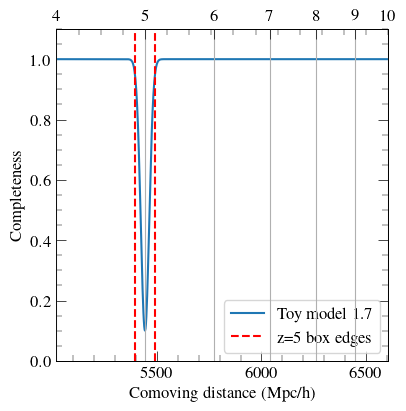

Average probability of detection:  0.5624151623361322


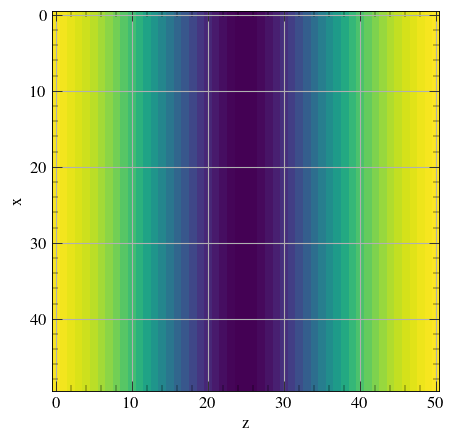

In [2]:
# toy1.7 model

func = gaussian(new_z_axis, red_com[1], 20, 0.9)

fig, ax = plt.subplots()
ax.plot(new_z_axis, func, label='Toy model 1.7')
ax.axvline(5392.76, color='r', linestyle='--', label='z=5 box edges')
ax.axvline(5492.76, color='r', linestyle='--')

ax.set_xlabel('Comoving distance (Mpc/h)')
ax.set_ylabel('Completeness')
ax.legend()
ax.grid(visible=False)
ax.set_box_aspect(1)
ax.set_ylim(0, 1.1)

# Add another twin axis for redshift
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(red_com)
ax2.set_xticklabels(redshifts)
ax2.set_box_aspect(1)

# save the plot as a pdf
plt.savefig(PLOT_DIRECTORY + 'Toy1.7_SelectionFunction.pdf', bbox_inches='tight')
plt.show()
# Let me first define the box around z=5. So we know the 100 cMpc/h box around z=5. It is given by red_com[1]-50 to red_com[1]+50.
# Now new_z_axis gives the comoving distance of the pixel centers. Left edge of the pixel is given by new_z_axis - pixel_size_z/2 and 
# right edge of the pixel is given by new_z_axis + pixel_size_z/2.
index = np.where(((new_z_axis+pixel_size_z/2) >= red_com[1]-50) & ((new_z_axis-pixel_size_z/2) <= red_com[1]+50))

# Defining the incomplete function.
incomp_func = np.ones((50, 50, 795)) * func

# now I want to visualize the incomp_func with these indices
incomp_func2d = np.average(incomp_func[:, :, index[0]], axis=0)
plt.figure(figsize=(5, 5))
plt.imshow(incomp_func2d)
plt.xlabel('z')
plt.ylabel('x')

# Find the fraction of quasar we will detect if the number of quasars is n->infinity.
print("Average probability of detection: ", np.average(incomp_func[:, :, index]))

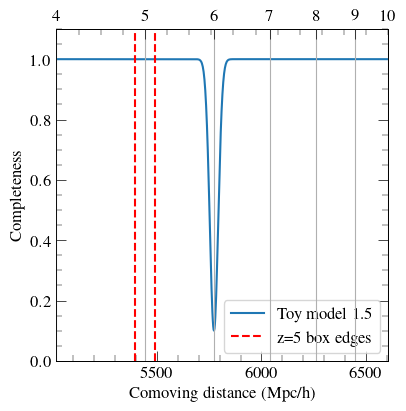

Average probability of detection:  1.0


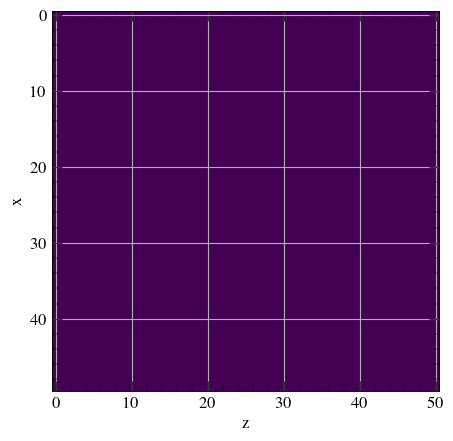

In [10]:
# toy1.8 model

func = gaussian(new_z_axis, red_com[2], 20, 0.9)

fig, ax = plt.subplots()
ax.plot(new_z_axis, func, label='Toy model 1.5')
ax.axvline(5392.76, color='r', linestyle='--', label='z=5 box edges')
ax.axvline(5492.76, color='r', linestyle='--')

ax.set_xlabel('Comoving distance (Mpc/h)')
ax.set_ylabel('Completeness')
ax.legend()
ax.grid(visible=False)
ax.set_box_aspect(1)
ax.set_ylim(0, 1.1)

# Add another twin axis for redshift
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(red_com)
ax2.set_xticklabels(redshifts)
ax2.set_box_aspect(1)

# save the plot as a pdf
plt.savefig(PLOT_DIRECTORY + 'Toy1.5_SelectionFunction.pdf', bbox_inches='tight')
plt.show()
# Let me first define the box around z=5. So we know the 100 cMpc/h box around z=5. It is given by red_com[1]-50 to red_com[1]+50.
# Now new_z_axis gives the comoving distance of the pixel centers. Left edge of the pixel is given by new_z_axis - pixel_size_z/2 and 
# right edge of the pixel is given by new_z_axis + pixel_size_z/2.
index = np.where(((new_z_axis+pixel_size_z/2) >= red_com[1]-50) & ((new_z_axis-pixel_size_z/2) <= red_com[1]+50))

# Defining the incomplete function.
incomp_func = np.ones((50, 50, 795)) * func

# now I want to visualize the incomp_func with these indices
incomp_func2d = np.average(incomp_func[:, :, index[0]], axis=0)
plt.figure(figsize=(5, 5))
plt.imshow(incomp_func2d)
plt.xlabel('z')
plt.ylabel('x')

# Find the fraction of quasar we will detect if the number of quasars is n->infinity.
print("Average probability of detection: ", np.average(incomp_func[:, :, index]))

In [3]:
print(red_com[0]+50)
print(red_com[0]+25)
print(red_com[0]+75)

5069.256490124303
5044.256490124303
5094.256490124303


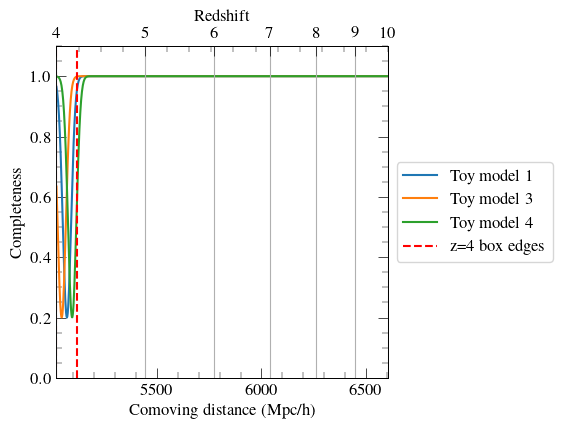

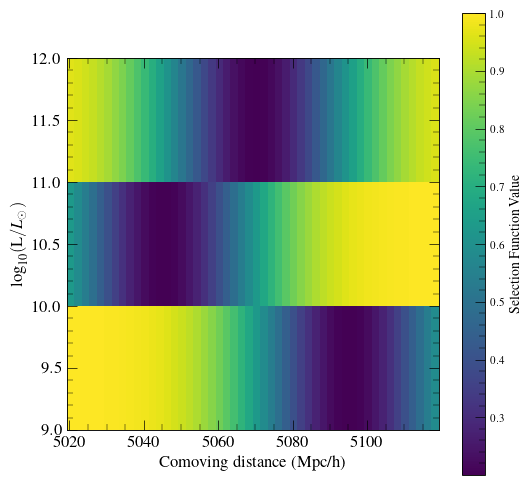

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# toy2.0 model
# Plot the selection function
fig, ax = plt.subplots()
ax2 = ax.twiny()
ax.plot(new_z_axis, gaussian(new_z_axis, 5069.27, 20, 0.8), label='Toy model 1')
ax.plot(new_z_axis, gaussian(new_z_axis, 5044.27, 20, 0.8), label='Toy model 3')
ax.plot(new_z_axis, gaussian(new_z_axis, 5094.27, 20, 0.8), label='Toy model 4')
ax.axvline(red_com[0], color='r', linestyle='--', label='z=4 box edges')
ax.axvline(red_com[0]+100, color='r', linestyle='--')
ax.set_xlabel('Comoving distance (Mpc/h)')
ax.set_ylabel('Completeness')
# Put the legend outside the plot
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.grid(visible=False)
ax.set_box_aspect(1)
ax.set_ylim(0, 1.1)

# Add another twin axis for redshift
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(red_com)
ax2.set_xticklabels(redshifts)
ax2.set_box_aspect(1)
ax2.set_xlabel('Redshift')

# ax.set_xlim(5300, 5600)
# ax2.set_xlim(5300, 5600)

# save the plot as a pdf
plt.savefig(PLOT_DIRECTORY + 'Toy2.0_SelectionFunction.pdf', bbox_inches='tight')
plt.show()

sel_func1 = gaussian(new_z_axis, 5069.27, 20, 0.8)
sel_func3 = gaussian(new_z_axis, 5044.27, 20, 0.8)
sel_func4 = gaussian(new_z_axis, 5094.27, 20, 0.8)

# Make a 2d array with the selection functions
sel_func = np.array([sel_func1, sel_func3, sel_func4])

# Make a 2D color plot
fig, ax = plt.subplots(figsize=(6, 6))

# Plot the selection functions
im = ax.imshow(
    sel_func,
    aspect='auto',
    extent=[new_z_axis[0], new_z_axis[-1], 9, 12],
    cmap='viridis'
)

# Set axis labels and properties
ax.set_xlabel('Comoving distance (Mpc/h)')
ax.set_ylabel(r'$\log_{10}(\mathrm{L}/L_{\odot})$')
# ax.set_title('Selection function')
ax.grid(visible=False)
ax.set_xlim(red_com[0], red_com[0] + 100)
ax.set_box_aspect(1)

# Add the color bar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Selection Function Value', fontsize=10)  # Add a label to the color bar
cbar.ax.tick_params(labelsize=8)  # Customize tick size for better readability

# Save the plot as a PDF
plt.savefig(PLOT_DIRECTORY + 'Toy2.0_SelectionFunction2D.pdf', bbox_inches='tight')

# Show the plot
plt.show()

In [6]:
print(red_com[1])
print(red_com[1]-25)
print(red_com[1]+25)

5442.7593468240075
5417.7593468240075
5467.7593468240075


Text(0.5, 0, 'Redshift')

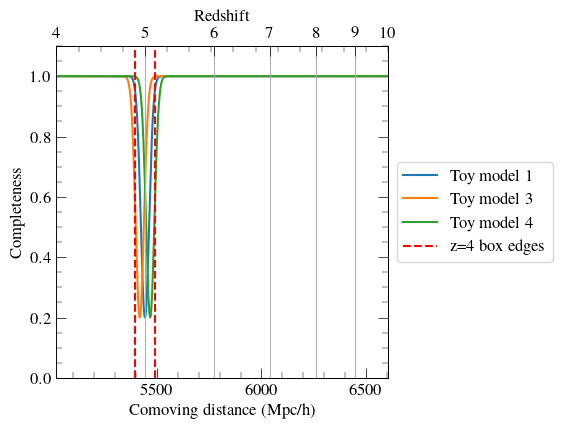

In [7]:
# toy2.1 model
# Plot the selection function
fig, ax = plt.subplots()
ax2 = ax.twiny()
ax.plot(new_z_axis, gaussian(new_z_axis, 5442.76, 20, 0.8), label='Toy model 1')
ax.plot(new_z_axis, gaussian(new_z_axis, 5417.76, 20, 0.8), label='Toy model 3')
ax.plot(new_z_axis, gaussian(new_z_axis, 5467.76, 20, 0.8), label='Toy model 4')
ax.axvline(red_com[1]-50, color='r', linestyle='--', label='z=4 box edges')
ax.axvline(red_com[1]+50, color='r', linestyle='--')
ax.set_xlabel('Comoving distance (Mpc/h)')
ax.set_ylabel('Completeness')
# Put the legend outside the plot
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.grid(visible=False)
ax.set_box_aspect(1)
ax.set_ylim(0, 1.1)

# Add another twin axis for redshift
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(red_com)
ax2.set_xticklabels(redshifts)
ax2.set_box_aspect(1)
ax2.set_xlabel('Redshift')

# ax.set_xlim(5300, 5600)
# ax2.set_xlim(5300, 5600)

In [8]:
print(red_com[2])
print(red_com[2]-25)
print(red_com[2]+25)

5772.844019771492
5747.844019771492
5797.844019771492


In [ ]:
# toy2.1 model
# Plot the selection function
fig, ax = plt.subplots()
ax2 = ax.twiny()
ax.plot(new_z_axis, gaussian(new_z_axis, 5772.84, 20, 0.8), label='Toy model 1')
ax.plot(new_z_axis, gaussian(new_z_axis, 5747.84, 20, 0.8), label='Toy model 3')
ax.plot(new_z_axis, gaussian(new_z_axis, 5797.84, 20, 0.8), label='Toy model 4')
ax.axvline(red_com[1]-50, color='r', linestyle='--', label='z=4 box edges')
ax.axvline(red_com[1]+50, color='r', linestyle='--')
ax.set_xlabel('Comoving distance (Mpc/h)')
ax.set_ylabel('Completeness')
# Put the legend outside the plot
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.grid(visible=False)
ax.set_box_aspect(1)
ax.set_ylim(0, 1.1)

# Add another twin axis for redshift
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(red_com)
ax2.set_xticklabels(redshifts)
ax2.set_box_aspect(1)
ax2.set_xlabel('Redshift')

# ax.set_xlim(5300, 5600)
# ax2.set_xlim(5300, 5600)

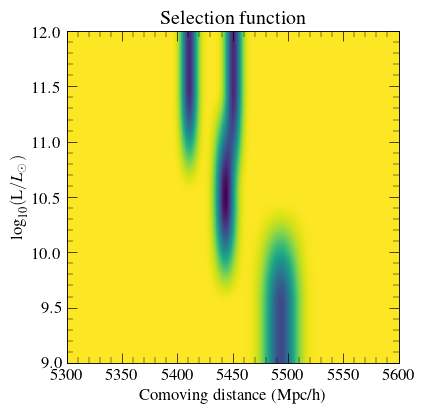

In [24]:
# Make the above plot into a 2d color plot with comoving distance on x axis and bolometric magnitude on y axis. Toy 1 corresponds to 
# 1e9 to 1e10 solar luminosities, toy 3 corresponds to 1e10 to 1e11 solar luminosities and toy 4 corresponds to 1e11 to 1e12 solar luminosities.
# I need the y axis 3 pixels across.

sel_func1 = gaussian2(new_z_axis, 5410, 5, 0.8, 5450, 5, 0.8)
sel_func3 = gaussian(new_z_axis, 5442.76, 6, 0.9)
sel_func4 = gaussian(new_z_axis, 5492.76, 10, 0.7)

# Make a 2d array with the selection functions
sel_func = np.array([sel_func1, sel_func3, sel_func4])

# Make a 2d color plot
fig, ax = plt.subplots()
ax.imshow(sel_func, aspect='auto', extent=[new_z_axis[0], new_z_axis[-1], 9, 12], cmap='viridis')
ax.set_xlabel('Comoving distance (Mpc/h)')
ax.set_ylabel(r'$\log_{10}(\mathrm{L}/L_{\odot})$')
ax.set_title('Selection function')
ax.grid(visible=False)
ax.set_xlim(5300, 5600)
ax.set_box_aspect(1)

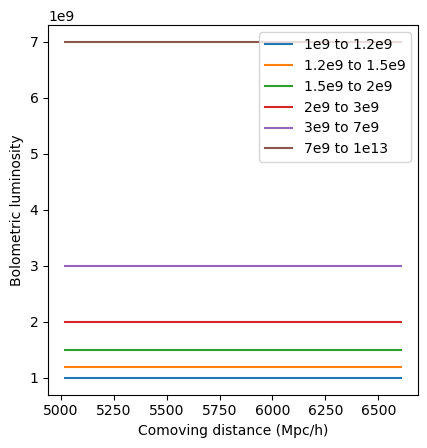

In [6]:
import numpy as np
from astropy.cosmology import FlatLambdaCDM
import matplotlib.pyplot as plt

# define the cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
h = 0.7

#----------------------------------------------------------------------------------------------------------------
# This whole section is done in a similar way to when I was creating the lightcone.

# Define the number of pixels in each dimension
num_pixels_x = 50
num_pixels_y = 50
num_pixels_z = 50

# Calculate the pixel size in each dimension in Mpch^-1
x_range = (0, 100) #(np.min(x_coordinates), np.max(x_coordinates))
y_range = (0, 100) #(np.min(y_coordinates), np.max(y_coordinates))
z_range = (0, 100) #(np.min(z_coordinates), np.max(z_coordinates))

pixel_size_x = (x_range[1] - x_range[0]) / num_pixels_x
pixel_size_y = (y_range[1] - y_range[0]) / num_pixels_y
pixel_size_z = pixel_size_x

# Define the redshifts.
redshifts = np.array([4, 5, 6, 7, 8, 9, 10])
red_com = cosmo.comoving_distance(redshifts).value * h

# Calculate the comoving distances
new_z_axis = cosmo.comoving_distance(redshifts).value * h  # Convert to h^-1 Mpc

# Define the redshifts for each slice of the lightcone.
new_z_axis = np.arange(new_z_axis[0], new_z_axis[-1], pixel_size_z)

bol_bins = np.array([[1e9, 1.2e9], [1.2e9, 1.5e9], [1.5e9, 2e9], [2e9, 3e9], [3e9, 7e9], [7e9, 1e13]])

# Make a bolometric luminosity vs redshift plot with horizontal lines at the bolometric luminosity bins.
fig, ax = plt.subplots()
ax.plot(new_z_axis, np.ones_like(new_z_axis) * bol_bins[0][0], label='1e9 to 1.2e9')
ax.plot(new_z_axis, np.ones_like(new_z_axis) * bol_bins[1][0], label='1.2e9 to 1.5e9')
ax.plot(new_z_axis, np.ones_like(new_z_axis) * bol_bins[2][0], label='1.5e9 to 2e9')
ax.plot(new_z_axis, np.ones_like(new_z_axis) * bol_bins[3][0], label='2e9 to 3e9')
ax.plot(new_z_axis, np.ones_like(new_z_axis) * bol_bins[4][0], label='3e9 to 7e9')
ax.plot(new_z_axis, np.ones_like(new_z_axis) * bol_bins[5][0], label='7e9 to 1e13')
ax.set_xlabel('Comoving distance (Mpc/h)')
ax.set_ylabel('Bolometric luminosity')
ax.legend()
ax.grid(visible=False)
ax.set_box_aspect(1)
# ax.set_ylim(1e9, 1e13)
